In [2]:
import kagglehub
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
import numpy as np
import torch.utils.data

path = kagglehub.dataset_download("jessicali9530/stanford-dogs-dataset")

composed_xform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=0.4397,std=0.2588),
])
ds = datasets.ImageFolder(root=path+'/images/Images', transform=composed_xform)
class_names = ds.classes

100%|██████████| 750M/750M [00:04<00:00, 162MB/s]

Extracting files...


In [2]:
variance_test_xform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
])
test_ds = datasets.ImageFolder(root=path+'/images/Images',
                               transform=variance_test_xform
                               )
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=100, shuffle=True)

means = []
stds = []
for batch in test_loader:
  images, labels = batch
  means.append(images.mean())
  stds.append(images.std())

mean = torch.tensor(means).mean()
std = torch.tensor(stds).mean()
print(mean, std)

tensor(0.4397) tensor(0.2588)


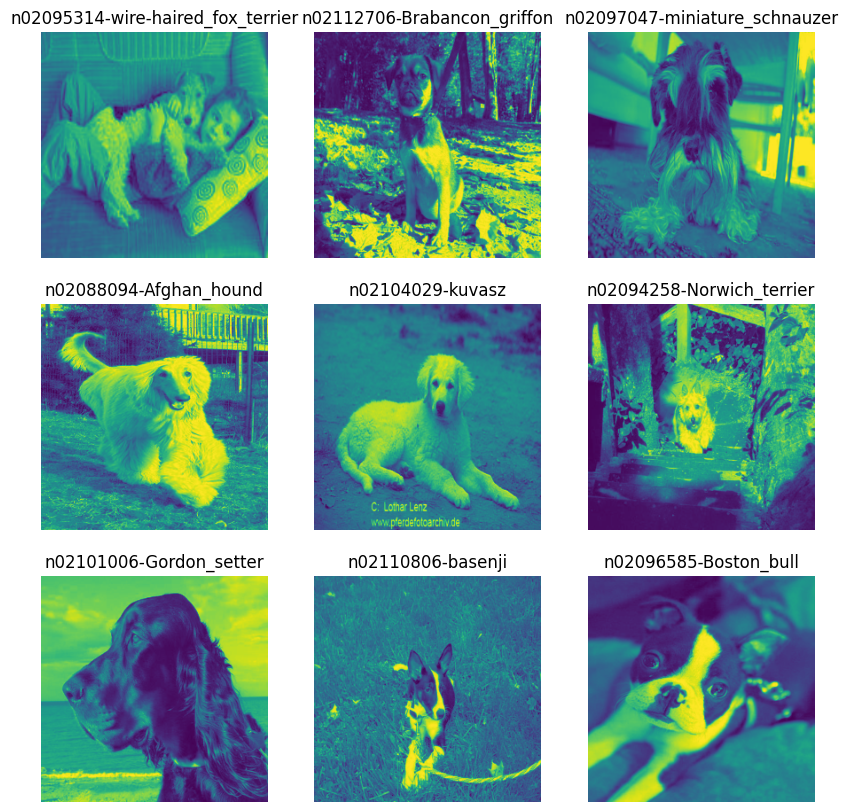

In [3]:
plt.figure(figsize=(10,10))
for i in range(9):
  idx = np.random.randint(0, len(ds))
  img, label = ds[idx]
  plt.subplot(3,3,i+1)
  plt.imshow(img[0])
  plt.axis('off')
  plt.title(class_names[label])


In [4]:
torch.manual_seed(42)
train_data, validation_data = torch.utils.data.random_split(ds, [0.8,0.2])
train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True)
validation_loader = torch.utils.data.DataLoader(validation_data, batch_size=32, shuffle=True)

In [10]:
from torch import device
model = models.resnet50(pretrained=False)
model.fc = nn.Linear(2048, 120)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

loss=nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [15]:
for param in model.parameters():
  param.requires_grad = True
for param in model.fc.parameters():
  param.requires_grad = True

In [26]:
def count_parameters(model):
  return sum(p.numel() for p in model.parameters() if p.requires_grad)
count_parameters(model)

23753912

In [27]:
def train_epoch(model, loss, optimizer, train_loader):
  moving_loss = []
  for batch in train_loader:
    images, labels = batch
    images = images.to(device)
    labels = labels.to(device)
    optimizer.zero_grad()

    preds = model(images)
    print(preds.shape)
    print(labels.shape)
    pred_loss = loss(preds, labels)
    pred_loss.backward()
    optimizer.step()
    print(f"batch loss {pred_loss.item()}")
    moving_loss.append(pred_loss.item())
  return np.mean(moving_loss)

def validate_epoch(model, validation_loader):
  moving_accuracy = []
  for batch in validation_loader:
    with torch.no_grad():
      images, labels = batch
      images = images.to(device)
      labels = labels.to(device)
      preds = model(images)
      accuracy = (preds.argmax(dim=1) == labels).float().mean()
      moving_accuracy.append(accuracy.item())
  return np.mean(moving_accuracy)

def train(model, loss, optimizer, train_loader, validation_loader, num_epochs):
  train_losses = []
  validation_accuracies = []
  for epoch in range(num_epochs):
    train_loss = train_epoch(model, loss, optimizer, train_loader)
    print(f"Epoch {epoch} train loss {train_loss}")
    validation_accuracy = validate_epoch(model, validation_loader)
    train_losses.append(train_loss)
    validation_accuracies.append(validation_accuracy)
    print(f"Epoch {epoch} validation accuracy {validation_accuracy}")
  return train_losses, validation_accuracies
train_losses, validation_accuracies = \
train(model, loss, optimizer, train_loader, validation_loader, 10)


torch.Size([32, 120])
torch.Size([32])
batch loss 9.003540992736816
torch.Size([32, 120])
torch.Size([32])
batch loss 7.266864776611328
torch.Size([32, 120])
torch.Size([32])
batch loss 6.552018165588379
torch.Size([32, 120])
torch.Size([32])
batch loss 5.431191921234131
torch.Size([32, 120])
torch.Size([32])
batch loss 5.829706192016602
torch.Size([32, 120])
torch.Size([32])


KeyboardInterrupt: 

In [28]:
from torch.utils.data import Subset
overfit_loader = torch.utils.data.DataLoader(Subset(ds, list(range(5000))), batch_size=32, shuffle=True)
train_losses, validation_accuracies = \
train(model, loss, optimizer, overfit_loader, overfit_loader, 10)

torch.Size([32, 120])
torch.Size([32])
batch loss 3.8322010040283203
torch.Size([32, 120])
torch.Size([32])
batch loss 3.826803684234619
torch.Size([32, 120])
torch.Size([32])
batch loss 3.793954372406006
torch.Size([32, 120])
torch.Size([32])
batch loss 3.6331889629364014
torch.Size([32, 120])
torch.Size([32])
batch loss 3.755424976348877
torch.Size([32, 120])
torch.Size([32])
batch loss 3.577410936355591
torch.Size([32, 120])
torch.Size([32])
batch loss 3.4837493896484375
torch.Size([32, 120])
torch.Size([32])
batch loss 3.533249855041504
torch.Size([32, 120])
torch.Size([32])
batch loss 3.5131356716156006
torch.Size([32, 120])
torch.Size([32])
batch loss 3.5096352100372314
torch.Size([32, 120])
torch.Size([32])
batch loss 3.3840177059173584
torch.Size([32, 120])
torch.Size([32])
batch loss 3.3967132568359375
torch.Size([32, 120])
torch.Size([32])
batch loss 3.4325289726257324
torch.Size([32, 120])
torch.Size([32])
batch loss 3.304986000061035
torch.Size([32, 120])
torch.Size([32])
b

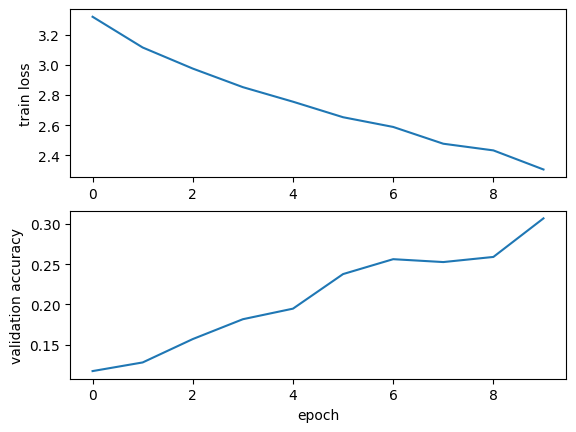

In [31]:
fig,ax = plt.subplots(2,1)
ax[0].plot(train_losses, label='train loss')
ax[1].plot(validation_accuracies, label='validation accuracy')
ax[0].set_ylabel('train loss')
ax[1].set_ylabel('validation accuracy')
ax[1].set_xlabel('epoch')
plt.savefig('from_scratch.png')

In [33]:
from torch import device
model_pretrained = models.resnet50(pretrained=True)
model_pretrained.fc = nn.Linear(2048, 120)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_pretrained = model_pretrained.to(device)

loss=nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_pretrained.parameters(), lr=5e-4)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [35]:
from torch.utils.data import Subset
overfit_loader = torch.utils.data.DataLoader(Subset(ds, list(range(10000))), batch_size=32, shuffle=True)
train_losses, validation_accuracies = \
train(model_pretrained, loss, optimizer, overfit_loader, overfit_loader, 10)

Streaming output truncated to the last 5000 lines.
torch.Size([32])
batch loss 0.5203726291656494
torch.Size([32, 120])
torch.Size([32])
batch loss 0.5322062373161316
torch.Size([32, 120])
torch.Size([32])
batch loss 0.6343508958816528
torch.Size([32, 120])
torch.Size([32])
batch loss 0.5943039655685425
torch.Size([32, 120])
torch.Size([32])
batch loss 0.47593122720718384
torch.Size([32, 120])
torch.Size([32])
batch loss 0.5269784927368164
torch.Size([32, 120])
torch.Size([32])
batch loss 0.3868914246559143
torch.Size([32, 120])
torch.Size([32])
batch loss 0.5219656229019165
torch.Size([32, 120])
torch.Size([32])
batch loss 0.8319239020347595
torch.Size([32, 120])
torch.Size([32])
batch loss 0.5139226913452148
torch.Size([32, 120])
torch.Size([32])
batch loss 0.5471771955490112
torch.Size([32, 120])
torch.Size([32])
batch loss 0.7763597369194031
torch.Size([32, 120])
torch.Size([32])
batch loss 0.5383531451225281
torch.Size([32, 120])
torch.Size([32])
batch loss 0.4885518252849579
torc

In [1]:
fig,ax = plt.subplots(2,1)
ax[0].plot(train_losses, label='train loss')
ax[1].plot(validation_accuracies, label='validation accuracy')
ax[0].set_ylabel('train loss')
ax[1].set_ylabel('validation accuracy')
ax[1].set_xlabel('epoch')
plt.savefig('pretrained.png')

NameError: name 'plt' is not defined

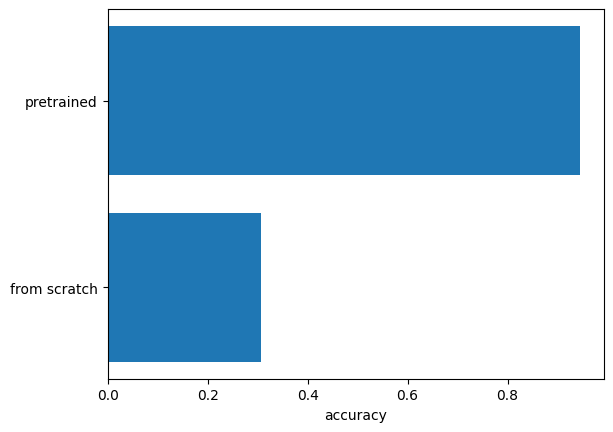

In [3]:
data = [0.30692675159235666, 0.944888178913738]
plt.barh(['from scratch', 'pretrained'], data)
plt.xlabel('accuracy')
plt.savefig('comparison.png')